#  NAS Leve com Metaheurísticas P9: Versão Multiobjetivo
## Equipe
Rayane Araújo, Júlia Júnior, Marcelo Soares, João Pedro e João Arthur.
**Disciplina:** INF0415 — Heurísticas e Modelagem Multiobjetivo · UFG 2026

##| **0** | Bibliotecas, dataset e configuração
##| **1** | Espaço de busca e modelo CNN dinâmico
##| **2** | Funções de treino, avaliação e fitness escalarizado
##| **3** | Metaheurísticas single-objective: AG, PBIL, Optuna
##| **4** |  **Baseline** — arquiteturas fixas manuais
##| **5** |  **NSGA-II** — versão multiobjetivo
##| **6** |  **Fronteira de Pareto inicial vs. evoluída**
##| **7** |  **Comparação completa** — baseline × single-obj × multiobj
##| **8** |  **Discussão de trade-offs**




## 0. Bibliotecas, Dataset e Configuração Global

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time, random, copy, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
import pandas as pd

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {DEVICE}')


#  PARÂMETROS GLOBAIS — ajuste aqui para execução rápida ou completa
POP_SIZE    = 6    # tamanho de população (AG, PBIL, NSGA-II)
GENERATIONS = 4    # gerações (AG, PBIL, NSGA-II)
N_TRIALS    = 12
MAX_PARAMS  = 500_000
MIN_ACC     = 90.0

print(f'Config: pop={POP_SIZE}, ger={GENERATIONS}, trials={N_TRIALS}')


Dispositivo: cuda
Config: pop=6, ger=4, trials=12


In [2]:
# ── Dataset MNIST ─────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=0)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=0)

print(f'Treino: {len(train_dataset)} imagens  |  Teste: {len(test_dataset)} imagens')


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 465kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.69MB/s]

Treino: 60000 imagens  |  Teste: 10000 imagens


## 1. Espaço de Busca e Modelo CNN Dinâmico

Cada **cromossomo** é um dicionário com:
- `n_layers` ∈ {1,2,3,4} — número de camadas convolucionais
- `filters` — lista de tamanho `n_layers`, cada valor ∈ {16,32,64,128}
- `activation` ∈ {`ReLU`, `LeakyReLU`}

A classe `DynamicCNN` constrói a rede automaticamente a partir desse dicionário.


In [3]:
SEARCH_SPACE = {
    'n_layers':   [1, 2, 3, 4],
    'filters':    [16, 32, 64, 128],
    'activation': ['ReLU', 'LeakyReLU']
}

class DynamicCNN(nn.Module):
    def __init__(self, config, input_shape=(1, 28, 28), num_classes=10):
        super().__init__()
        self.config = config
        act_fn = nn.ReLU if config['activation'] == 'ReLU' else nn.LeakyReLU
        self.features = nn.Sequential()
        in_ch = input_shape[0]
        for i, out_ch in enumerate(config['filters']):
            self.features.add_module(f'conv_{i+1}', nn.Conv2d(in_ch, out_ch, 3, padding=1))
            self.features.add_module(f'act_{i+1}',  act_fn())
            self.features.add_module(f'pool_{i+1}', nn.MaxPool2d(2, 2))
            in_ch = out_ch
        with torch.no_grad():
            flat_sz = self.features(torch.zeros(1, *input_shape)).view(-1).shape[0]
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(flat_sz, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def config_repr(cfg):
    return f"L{cfg['n_layers']} | F{cfg['filters']} | {cfg['activation']}"

print("DynamicCNN e espaço de busca carregados.")


DynamicCNN e espaço de busca carregados.


## 2. Funções de Treinamento, Avaliação e Fitness

### Três objetivos (usados no NSGA-II):
| Objetivo | Direção | Descrição |
|---|---|---|
| **f₁** | Maximizar | Acurácia no conjunto de teste (%) |
| **f₂** | Minimizar | Número de parâmetros treináveis |
| **f₃** | Minimizar | Tempo médio de inferência por lote (ms) |

### Fitness escalarizado (usado no AG / PBIL / Optuna — single-objective):
Combina f₁, f₂ e penalidades em um único número para comparação direta.


In [4]:
def train_model(model, loader, epochs=1, device=DEVICE):
    model.to(device).train()
    opt = optim.Adam(model.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()
    t0 = time.time()
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); crit(model(x), y).backward(); opt.step()
    return time.time() - t0

def evaluate_model(model, loader, device=DEVICE):
    """Retorna (acurácia %, tempo_inf_médio ms)."""
    model.to(device).eval()
    correct = total = 0
    inf_times = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            t0 = time.time()
            out = model(x)
            inf_times.append((time.time() - t0) * 1000)
            correct += (out.argmax(1) == y).sum().item()
            total   += y.size(0)
    return 100 * correct / total, float(np.mean(inf_times))

def evaluate_config(config, device=DEVICE):
    """Avalia uma configuração e retorna (f1_acc, f2_params, f3_inf_ms, fitness_escalar)."""
    model = DynamicCNN(config).to(device)
    f2 = count_params(model)
    if f2 > MAX_PARAMS:
        return 0.0, f2, 999.0, -100.0
    train_model(model, train_loader, epochs=1, device=device)
    f1, f3 = evaluate_model(model, test_loader, device=device)
    fitness = calculate_fitness(f1, f2)
    return f1, f2, f3, fitness

def calculate_fitness(accuracy, num_params):
    """Fitness escalarizado (single-objective)."""
    fit = accuracy
    if num_params > MAX_PARAMS:
        fit -= (num_params / MAX_PARAMS) * 20
    if accuracy < MIN_ACC:
        fit -= 20
    if num_params <= MAX_PARAMS:
        fit += ((MAX_PARAMS - num_params) / MAX_PARAMS) * 2.0
    return fit

print("Funções de avaliação carregadas.")


Funções de avaliação carregadas.


## 3. Metaheurísticas Single-Objective (AG, PBIL, Optuna)

Estas são as metaheurísticas originais do projeto. Cada uma retorna **uma única melhor solução**
usando o fitness escalarizado. Aqui as executamos e armazenamos os resultados para a
comparação final.


In [5]:
# ── Operadores Genéticos ──────────────────────────────────────────────────────
def random_individual():
    n = random.choice(SEARCH_SPACE['n_layers'])
    return {'n_layers': n,
            'filters':  [random.choice(SEARCH_SPACE['filters']) for _ in range(n)],
            'activation': random.choice(SEARCH_SPACE['activation'])}

def crossover(p1, p2):
    n = random.choice([p1['n_layers'], p2['n_layers']])
    filters = []
    for i in range(n):
        f1 = p1['filters'][i] if i < p1['n_layers'] else random.choice(SEARCH_SPACE['filters'])
        f2 = p2['filters'][i] if i < p2['n_layers'] else random.choice(SEARCH_SPACE['filters'])
        filters.append(random.choice([f1, f2]))
    return {'n_layers': n, 'filters': filters,
            'activation': random.choice([p1['activation'], p2['activation']])}

def mutate(ind, rate=0.2):
    ind = copy.deepcopy(ind)
    if random.random() < rate:
        ind['n_layers'] = random.choice(SEARCH_SPACE['n_layers'])
        while len(ind['filters']) < ind['n_layers']:
            ind['filters'].append(random.choice(SEARCH_SPACE['filters']))
        ind['filters'] = ind['filters'][:ind['n_layers']]
    for i in range(ind['n_layers']):
        if random.random() < rate:
            ind['filters'][i] = random.choice(SEARCH_SPACE['filters'])
    if random.random() < rate:
        ind['activation'] = random.choice(SEARCH_SPACE['activation'])
    return ind

def tournament(pop, scores, k=2):
    candidates = random.sample(list(zip(pop, scores)), k)
    return max(candidates, key=lambda x: x[1])[0]


In [6]:
# ── Algoritmo Genético ────────────────────────────────────────────────────────
def genetic_algorithm(pop_size=POP_SIZE, generations=GENERATIONS):
    print(f"\n{'='*60}")
    print(f" AG — pop={pop_size}, ger={generations}")
    print(f"{'='*60}")
    pop = [random_individual() for _ in range(pop_size)]
    best_cfg, best_fit = None, -float('inf')
    history = []

    for g in range(generations):
        scores, results = [], []
        for ind in pop:
            f1, f2, f3, fit = evaluate_config(ind)
            scores.append(fit)
            results.append((f1, f2, f3))
            print(f"  Gen{g+1} | Fit={fit:7.2f} | Acc={f1:5.2f}% | Params={f2:,} | {config_repr(ind)}")

        best_i = int(np.argmax(scores))
        if scores[best_i] > best_fit:
            best_fit, best_cfg = scores[best_i], pop[best_i]
        history.append(best_fit)
        print(f"  ★ Melhor Geração {g+1}: Fit={best_fit:.2f}")

        new_pop = [pop[best_i]]
        while len(new_pop) < pop_size:
            new_pop.append(mutate(crossover(tournament(pop, scores), tournament(pop, scores))))
        pop = new_pop

    f1, f2, f3, _ = evaluate_config(best_cfg)
    print(f"\n  ✅ AG Final → Acc={f1:.2f}%, Params={f2:,}, InfTime={f3:.2f}ms")
    return best_cfg, history, (f1, f2, f3)

results_ag = genetic_algorithm()
best_cfg_ag, hist_ag, obj_ag = results_ag



 AG — pop=6, ger=4
  Gen1 | Fit=  98.12 | Acc=96.25% | Params=31,530 | L1 | F[16] | LeakyReLU
  Gen1 | Fit=  99.67 | Acc=97.77% | Params=25,258 | L2 | F[32, 32] | ReLU
  Gen1 | Fit=  98.37 | Acc=97.38% | Params=252,170 | L1 | F[128] | ReLU
  Gen1 | Fit=  98.89 | Acc=97.02% | Params=31,530 | L1 | F[16] | ReLU
  Gen1 | Fit=  99.67 | Acc=97.75% | Params=20,490 | L2 | F[16, 32] | LeakyReLU
  Gen1 | Fit= 100.17 | Acc=98.60% | Params=106,442 | L2 | F[128, 64] | ReLU
  ★ Melhor Geração 1: Fit=100.17
  Gen2 | Fit=  99.88 | Acc=98.31% | Params=106,442 | L2 | F[128, 64] | ReLU
  Gen2 | Fit=  99.27 | Acc=97.52% | Params=63,050 | L1 | F[32] | ReLU
  Gen2 | Fit=  98.37 | Acc=97.38% | Params=252,170 | L1 | F[128] | ReLU
  Gen2 | Fit=  99.82 | Acc=97.90% | Params=20,490 | L2 | F[16, 32] | LeakyReLU
  Gen2 | Fit= 100.22 | Acc=98.44% | Params=53,866 | L2 | F[128, 32] | ReLU
  Gen2 | Fit= 100.34 | Acc=98.62% | Params=68,938 | L2 | F[64, 64] | ReLU
  ★ Melhor Geração 2: Fit=100.34
  Gen3 | Fit= 100.14 |

In [ ]:
# ── PBIL ──────────────────────────────────────────────────────────────────────
class PBIL:
    def __init__(self, lr=0.1, mut_rate=0.05, mut_shift=0.05):
        self.lr, self.mut_rate, self.mut_shift = lr, mut_rate, mut_shift
        n_f = len(SEARCH_SPACE['filters'])
        n_n = len(SEARCH_SPACE['n_layers'])
        n_a = len(SEARCH_SPACE['activation'])
        self.p = {
            'n_layers':   {k: 1/n_n for k in SEARCH_SPACE['n_layers']},
            'activation': {k: 1/n_a for k in SEARCH_SPACE['activation']},
            'filters':    [{k: 1/n_f for k in SEARCH_SPACE['filters']}
                           for _ in range(max(SEARCH_SPACE['n_layers']))]
        }

    def sample(self, d): return np.random.choice(list(d.keys()), p=list(d.values()))

    def generate(self):
        n = self.sample(self.p['n_layers'])
        return {'n_layers': n,
                'filters':  [self.sample(self.p['filters'][i]) for i in range(n)],
                'activation': self.sample(self.p['activation'])}

    def update(self, best):
        for k in self.p['n_layers']:
            self.p['n_layers'][k] = self.p['n_layers'][k]*(1-self.lr) + (1.0 if k==best['n_layers'] else 0)*self.lr
        for k in self.p['activation']:
            self.p['activation'][k] = self.p['activation'][k]*(1-self.lr) + (1.0 if k==best['activation'] else 0)*self.lr
        for i in range(best['n_layers']):
            for k in self.p['filters'][i]:
                self.p['filters'][i][k] = self.p['filters'][i][k]*(1-self.lr) + (1.0 if k==best['filters'][i] else 0)*self.lr
        for d in [self.p['n_layers'], self.p['activation']] + self.p['filters']:
            self._mut(d)

    def _mut(self, d):
        for k in d:
            if np.random.random() < self.mut_rate:
                d[k] = max(0.01, min(0.99, d[k] + (1 if np.random.random()>.5 else -1)*self.mut_shift))
        s = sum(d.values())
        for k in d: d[k] /= s

def pbil_search(pop_size=POP_SIZE, generations=GENERATIONS):
    print(f"\n{'='*60}")
    print(f" PBIL — pop={pop_size}, ger={generations}")
    print(f"{'='*60}")
    pbil = PBIL()
    best_cfg, best_fit = None, -float('inf')
    history = []

    for g in range(generations):
        pop = [pbil.generate() for _ in range(pop_size)]
        scores = []
        for ind in pop:
            f1, f2, f3, fit = evaluate_config(ind)
            scores.append(fit)
            print(f"  Gen{g+1} | Fit={fit:7.2f} | Acc={f1:5.2f}% | Params={f2:,} | {config_repr(ind)}")
        best_i = int(np.argmax(scores))
        if scores[best_i] > best_fit:
            best_fit, best_cfg = scores[best_i], pop[best_i]
        history.append(best_fit)
        pbil.update(pop[best_i])
        print(f"  ★ Melhor Geração {g+1}: Fit={best_fit:.2f}")

    f1, f2, f3, _ = evaluate_config(best_cfg)
    print(f"\n  ✅ PBIL Final → Acc={f1:.2f}%, Params={f2:,}, InfTime={f3:.2f}ms")
    return best_cfg, history, (f1, f2, f3)

results_pbil = pbil_search()
best_cfg_pbil, hist_pbil, obj_pbil = results_pbil



 PBIL — pop=6, ger=4
  Gen1 | Fit= 100.11 | Acc=98.54% | Params=106,442 | L2 | F[np.int64(128), np.int64(64)] | LeakyReLU
  Gen1 | Fit=  98.88 | Acc=97.01% | Params=31,530 | L1 | F[np.int64(16)] | ReLU
  Gen1 | Fit=  99.23 | Acc=97.50% | Params=66,650 | L4 | F[np.int64(64), np.int64(64), np.int64(16), np.int64(128)] | LeakyReLU
  Gen1 | Fit=  98.74 | Acc=96.87% | Params=31,530 | L1 | F[np.int64(16)] | ReLU
  Gen1 | Fit= 100.08 | Acc=98.22% | Params=34,794 | L2 | F[np.int64(64), np.int64(32)] | ReLU
  Gen1 | Fit=  99.60 | Acc=97.67% | Params=16,938 | L3 | F[np.int64(16), np.int64(32), np.int64(32)] | ReLU
  ★ Melhor Geração 1: Fit=100.11
  Gen2 | Fit=  98.53 | Acc=97.54% | Params=252,170 | L1 | F[np.int64(128)] | LeakyReLU
  Gen2 | Fit=  99.44 | Acc=98.11% | Params=167,546 | L4 | F[np.int64(128), np.int64(64), np.int64(128), np.int64(16)] | ReLU
  Gen2 | Fit=  98.87 | Acc=97.12% | Params=63,050 | L1 | F[np.int64(32)] | ReLU
  Gen2 | Fit= 100.12 | Acc=98.34% | Params=53,866 | L2 | F[np.

In [12]:
# ── Optuna (TPE) ──────────────────────────────────────────────────────────────
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def optuna_objective(trial):
    n = trial.suggest_categorical('n_layers', SEARCH_SPACE['n_layers'])
    act = trial.suggest_categorical('activation', SEARCH_SPACE['activation'])
    filters = [trial.suggest_categorical(f'f{i}', SEARCH_SPACE['filters']) for i in range(n)]
    cfg = {'n_layers': n, 'filters': filters, 'activation': act}
    f1, f2, f3, fit = evaluate_config(cfg)
    trial.set_user_attr('f1_acc',   f1)
    trial.set_user_attr('f2_params', f2)
    trial.set_user_attr('f3_inf',   f3)
    if f2 > MAX_PARAMS: raise optuna.TrialPruned()
    return fit

def optuna_search(n_trials=N_TRIALS):
    print(f"\n{'='*60}")
    print(f" Optuna TPE — {n_trials} trials")
    print(f"{'='*60}")
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    best_so_far = -float('inf')
    history = []
    for i in range(n_trials):
        study.optimize(optuna_objective, n_trials=1)
        t = study.trials[-1]
        if t.state == optuna.trial.TrialState.COMPLETE:
            best_so_far = max(best_so_far, t.value)
            print(f"  Trial {t.number:2d} | Fit={t.value:7.2f} | Acc={t.user_attrs.get('f1_acc',0):.2f}% | {t.params}")
        else:
            print(f"  Trial {t.number:2d} | PRUNED")
        history.append(max(best_so_far, 0))

    bt = study.best_trial
    f1 = bt.user_attrs.get('f1_acc', 0)
    f2 = bt.user_attrs.get('f2_params', 0)
    f3 = bt.user_attrs.get('f3_inf', 0)
    n  = bt.params['n_layers']
    act = bt.params['activation']
    filters = [bt.params[f'f{i}'] for i in range(n)]
    best_cfg = {'n_layers': n, 'filters': filters, 'activation': act}
    print(f"\n  ✅ Optuna Final → Acc={f1:.2f}%, Params={f2:,}, InfTime={f3:.2f}ms")
    return best_cfg, history, (f1, f2, f3), study

results_optuna = optuna_search()
best_cfg_opt, hist_opt, obj_opt, study_opt = results_optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.1 MB/s eta 0:00:00

 Optuna TPE — 12 trials
  Trial  0 | Fit=  99.93 | Acc=98.03% | {'n_layers': 2, 'activation': 'ReLU', 'f0': 32, 'f1': 32}
  Trial  1 | Fit=  99.47 | Acc=97.71% | {'n_layers': 4, 'activation': 'ReLU', 'f0': 16, 'f1': 32, 'f2': 64, 'f3': 64}
  Trial  2 | Fit=  99.37 | Acc=97.49% | {'n_layers': 3, 'activation': 'LeakyReLU', 'f0': 32, 'f1': 64, 'f2': 16}
  Trial  3 | Fit=  99.70 | Acc=98.25% | {'n_layers': 2, 'activation': 'LeakyReLU', 'f0': 64, 'f1': 128}
  Trial  4 | Fit= 100.14 | Acc=98.42% | {'n_layers': 2, 'activation': 'LeakyReLU', 'f0': 64, 'f1': 64}
  Trial  5 | Fit=  98.79 | Acc=96.92% | {'n_layers': 1, 'activation': 'ReLU', 'f0': 16}
  Trial  6 | Fit=  99.69 | Acc=98.08% | {'n_layers': 3, 'activation': 'ReLU', 'f0': 128, 'f1': 64, 'f2': 32}
  Trial  7 | Fit= 100.47 | Acc=98.74% | {'n_layers': 3, 'activation': 'LeakyReLU', 'f0': 64, 'f1': 32, 'f2': 128}
  Trial  8 | Fit=  99.82 | Acc=97.90% | {'n_lay

## 4. 🆕 Baseline — Arquiteturas Fixas Manuais

Antes de comparar as metaheurísticas, precisamos de uma **referência**:
arquiteturas projetadas à mão que representam escolhas típicas de um engenheiro.

| Nome | Configuração | Expectativa |
|---|---|---|
| **Tiny** | 1 camada, 16 filtros | Muito rápida, pouca acurácia |
| **Small** | 2 camadas, [32, 32] | Bom equilíbrio leve |
| **Medium** | 2 camadas, [64, 128] | Acurácia razoável, médio peso |
| **Large** | 3 camadas, [64, 128, 128] | Alta acurácia, mais pesada |
| **XLarge** | 4 camadas, [128, 128, 128, 128] | Máxima capacidade no espaço |


In [13]:
BASELINES = {
    'Tiny':   {'n_layers': 1, 'filters': [16],              'activation': 'ReLU'},
    'Small':  {'n_layers': 2, 'filters': [32, 32],          'activation': 'ReLU'},
    'Medium': {'n_layers': 2, 'filters': [64, 128],         'activation': 'ReLU'},
    'Large':  {'n_layers': 3, 'filters': [64, 128, 128],    'activation': 'ReLU'},
    'XLarge': {'n_layers': 4, 'filters': [128, 128, 128, 128], 'activation': 'ReLU'},
}

print(f"{'='*60}")
print(" BASELINE — avaliando arquiteturas manuais")
print(f"{'='*60}")

baseline_results = {}
for name, cfg in BASELINES.items():
    f1, f2, f3, fit = evaluate_config(cfg)
    baseline_results[name] = {'config': cfg, 'f1_acc': f1, 'f2_params': f2, 'f3_inf': f3, 'fitness': fit}
    print(f"  {name:8s} | Acc={f1:6.2f}% | Params={f2:8,} | InfTime={f3:.2f}ms | Fit={fit:.2f}")

print("\nBaseline concluído.")


 BASELINE — avaliando arquiteturas manuais
  Tiny     | Acc= 96.28% | Params=  31,530 | InfTime=0.27ms | Fit=98.15
  Small    | Acc= 97.74% | Params=  25,258 | InfTime=0.49ms | Fit=99.64
  Medium   | Acc= 98.70% | Params= 137,226 | InfTime=0.58ms | Fit=100.15
  Large    | Acc= 98.93% | Params= 233,610 | InfTime=0.51ms | Fit=100.00
  XLarge   | Acc= 98.40% | Params= 445,322 | InfTime=0.62ms | Fit=98.62

Baseline concluído.


## 5. 🆕 NSGA-II — Otimização Multiobjetivo

O **NSGA-II** (Non-dominated Sorting Genetic Algorithm II, Deb et al. 2002) é o algoritmo
multiobjetivo mais usado na literatura. Ele substitui o fitness escalar por **dois critérios**:

1. **Rank de dominância (non-dominated sorting):**
   Uma solução `a` *domina* `b` se for melhor em pelo menos um objetivo e não pior em nenhum.
   O front 0 (rank=0) contém as soluções que ninguém domina — a **fronteira de Pareto**.

2. **Crowding distance:**
   Dentro do mesmo rank, soluções mais *isoladas* (distantes das vizinhas) são preferidas,
   pois mantêm diversidade na fronteira.

### Nossos 3 objetivos (todos minimizados internamente):
- **o₁ = 100 − acurácia** (minimizar → maximiza acurácia)
- **o₂ = num_params / MAX_PARAMS** (minimizar → rede mais leve)
- **o₃ = inf_time_ms** (minimizar → mais rápida)


In [14]:
# ── Núcleo do NSGA-II ──────────────────────────────────────────────────────────

def objectives(f1_acc, f2_params, f3_inf):
    """Converte métricas em vetor de objetivos a minimizar."""
    return [100.0 - f1_acc,
            f2_params / MAX_PARAMS,
            f3_inf]

def dominates(a, b):
    """True se 'a' domina 'b' (todos obj de a <= b e pelo menos um <)."""
    return all(ai <= bi for ai, bi in zip(a, b)) and any(ai < bi for ai, bi in zip(a, b))

def fast_nondominated_sort(pop_objs):
    """Retorna lista de fronts (cada front = lista de índices)."""
    n = len(pop_objs)
    dom_count  = [0] * n          # quantos dominam i
    dom_set    = [[] for _ in range(n)]  # quem i domina
    fronts     = [[]]

    for i in range(n):
        for j in range(i+1, n):
            if dominates(pop_objs[i], pop_objs[j]):
                dom_set[i].append(j); dom_count[j] += 1
            elif dominates(pop_objs[j], pop_objs[i]):
                dom_set[j].append(i); dom_count[i] += 1
        if dom_count[i] == 0:
            fronts[0].append(i)

    k = 0
    while fronts[k]:
        next_front = []
        for i in fronts[k]:
            for j in dom_set[i]:
                dom_count[j] -= 1
                if dom_count[j] == 0:
                    next_front.append(j)
        k += 1
        fronts.append(next_front)
    return [f for f in fronts if f]

def crowding_distance(front_objs):
    """Calcula crowding distance para os indivíduos de um front."""
    n = len(front_objs)
    if n <= 2: return [float('inf')] * n
    n_obj = len(front_objs[0])
    dist  = [0.0] * n
    for m in range(n_obj):
        vals  = [front_objs[i][m] for i in range(n)]
        order = sorted(range(n), key=lambda i: vals[i])
        dist[order[0]] = dist[order[-1]] = float('inf')
        span = vals[order[-1]] - vals[order[0]]
        if span == 0: continue
        for k in range(1, n-1):
            dist[order[k]] += (vals[order[k+1]] - vals[order[k-1]]) / span
    return dist

def nsga2_select(pop, pop_objs, n):
    """Seleciona n indivíduos pelos critérios NSGA-II."""
    fronts = fast_nondominated_sort(pop_objs)
    selected, ranks, crowdings = [], [], []
    rank_map = {}; crowd_map = {}

    for r, front in enumerate(fronts):
        cd = crowding_distance([pop_objs[i] for i in front])
        for idx, i in enumerate(front):
            rank_map[i] = r
            crowd_map[i] = cd[idx]

    all_idx = list(range(len(pop)))
    all_idx.sort(key=lambda i: (rank_map.get(i, 999), -crowd_map.get(i, 0)))
    return [pop[i] for i in all_idx[:n]], [pop_objs[i] for i in all_idx[:n]]

def nsga2_tournament(pop, pop_objs, rank_map, crowd_map):
    """Torneio binário NSGA-II."""
    i, j = random.sample(range(len(pop)), 2)
    ri, rj = rank_map.get(i, 999), rank_map.get(j, 999)
    if ri < rj: return pop[i]
    if rj < ri: return pop[j]
    return pop[i] if crowd_map.get(i, 0) >= crowd_map.get(j, 0) else pop[j]

print("Núcleo NSGA-II carregado.")


Núcleo NSGA-II carregado.


In [15]:
# ── Loop Principal NSGA-II ────────────────────────────────────────────────────

def nsga2_search(pop_size=POP_SIZE, generations=GENERATIONS):
    print(f"\n{'='*60}")
    print(f" NSGA-II — pop={pop_size}, ger={generations}")
    print(f"{'='*60}")

    # Inicialização
    pop = [random_individual() for _ in range(pop_size)]
    pop_objs = []
    print("  ── Avaliando população inicial...")
    for ind in pop:
        f1, f2, f3, _ = evaluate_config(ind)
        pop_objs.append(objectives(f1, f2, f3))

    # ★ Salvar fronteira de Pareto inicial (antes de evoluir)
    fronts_init = fast_nondominated_sort(pop_objs)
    pareto_init_objs = [pop_objs[i] for i in fronts_init[0]]
    pareto_init_cfgs = [pop[i]      for i in fronts_init[0]]
    print(f"  Fronteira Pareto inicial: {len(pareto_init_cfgs)} soluções não-dominadas")

    history_hv = []  # hipervolume proxy por geração

    for g in range(generations):
        # Calcular ranks e crowding
        fronts   = fast_nondominated_sort(pop_objs)
        rank_map = {}; crowd_map = {}
        for r, front in enumerate(fronts):
            cd = crowding_distance([pop_objs[i] for i in front])
            for k, i in enumerate(front):
                rank_map[i] = r; crowd_map[i] = cd[k]

        # Gerar filhos
        offspring = []
        offspring_objs = []
        while len(offspring) < pop_size:
            p1 = nsga2_tournament(pop, pop_objs, rank_map, crowd_map)
            p2 = nsga2_tournament(pop, pop_objs, rank_map, crowd_map)
            child = mutate(crossover(p1, p2))
            f1, f2, f3, _ = evaluate_config(child)
            offspring.append(child)
            offspring_objs.append(objectives(f1, f2, f3))

        # Selecionar próxima geração de pop_size*2 → pop_size
        combined      = pop + offspring
        combined_objs = pop_objs + offspring_objs
        pop, pop_objs = nsga2_select(combined, combined_objs, pop_size)

        # Métricas da geração
        fronts_g = fast_nondominated_sort(pop_objs)
        pareto_g = fronts_g[0]
        n_pareto = len(pareto_g)
        best_acc = max(100 - pop_objs[i][0] for i in pareto_g)
        min_par  = min(pop_objs[i][1] * MAX_PARAMS for i in pareto_g)

        # Proxy hipervolume: área dominada na projeção f1×f2
        ref = [100.0, 1.0]  # ponto de referência (pior possível normalizado)
        hv_proxy = sum((ref[0] - pop_objs[i][0]) * (ref[1] - pop_objs[i][1])
                       for i in pareto_g if pop_objs[i][0] < ref[0] and pop_objs[i][1] < ref[1])
        history_hv.append(hv_proxy)

        print(f"  Gen{g+1:2d} | Front0={n_pareto:2d} soluções | BestAcc={best_acc:.2f}% | MinParams={min_par:,.0f} | HV={hv_proxy:.4f}")

    # Fronteira de Pareto final
    fronts_final = fast_nondominated_sort(pop_objs)
    pareto_final_objs = [pop_objs[i] for i in fronts_final[0]]
    pareto_final_cfgs = [pop[i]      for i in fronts_final[0]]

    print(f"\n  ✅ NSGA-II Final: {len(pareto_final_cfgs)} soluções na fronteira de Pareto")
    for i, (cfg, obj) in enumerate(zip(pareto_final_cfgs, pareto_final_objs)):
        acc = 100 - obj[0]
        params = obj[1] * MAX_PARAMS
        inf_ms = obj[2]
        print(f"     [{i:2d}] Acc={acc:.2f}% | Params={params:,.0f} | Inf={inf_ms:.2f}ms | {config_repr(cfg)}")

    return (pareto_final_cfgs, pareto_final_objs,
            pareto_init_cfgs,  pareto_init_objs,
            history_hv)

nsga2_results = nsga2_search()
pareto_final_cfgs, pareto_final_objs, pareto_init_cfgs, pareto_init_objs, hist_hv = nsga2_results



 NSGA-II — pop=6, ger=4
  ── Avaliando população inicial...
  Fronteira Pareto inicial: 5 soluções não-dominadas
  Gen 1 | Front0= 6 soluções | BestAcc=98.53% | MinParams=20,490 | HV=445.5342
  Gen 2 | Front0= 6 soluções | BestAcc=98.73% | MinParams=20,490 | HV=458.2317
  Gen 3 | Front0= 6 soluções | BestAcc=98.73% | MinParams=20,490 | HV=458.3061
  Gen 4 | Front0= 6 soluções | BestAcc=98.73% | MinParams=20,490 | HV=460.0730

  ✅ NSGA-II Final: 6 soluções na fronteira de Pareto
     [ 0] Acc=97.82% | Params=20,490 | Inf=0.39ms | L2 | F[16, 32] | LeakyReLU
     [ 1] Acc=98.73% | Params=62,442 | Inf=0.48ms | L3 | F[128, 32, 64] | ReLU
     [ 2] Acc=97.28% | Params=252,170 | Inf=0.29ms | L1 | F[128] | LeakyReLU
     [ 3] Acc=96.89% | Params=31,530 | Inf=0.26ms | L1 | F[16] | LeakyReLU
     [ 4] Acc=97.93% | Params=27,258 | Inf=0.60ms | L3 | F[128, 16, 32] | ReLU
     [ 5] Acc=97.39% | Params=252,170 | Inf=0.33ms | L1 | F[128] | LeakyReLU


## 6. 🆕 Fronteira de Pareto: Inicial vs. Evoluída

Aqui visualizamos **o quanto o NSGA-II melhorou** em relação à população aleatória inicial.
Uma fronteira mais próxima do canto superior-esquerdo (alta acurácia, poucos parâmetros) é melhor.


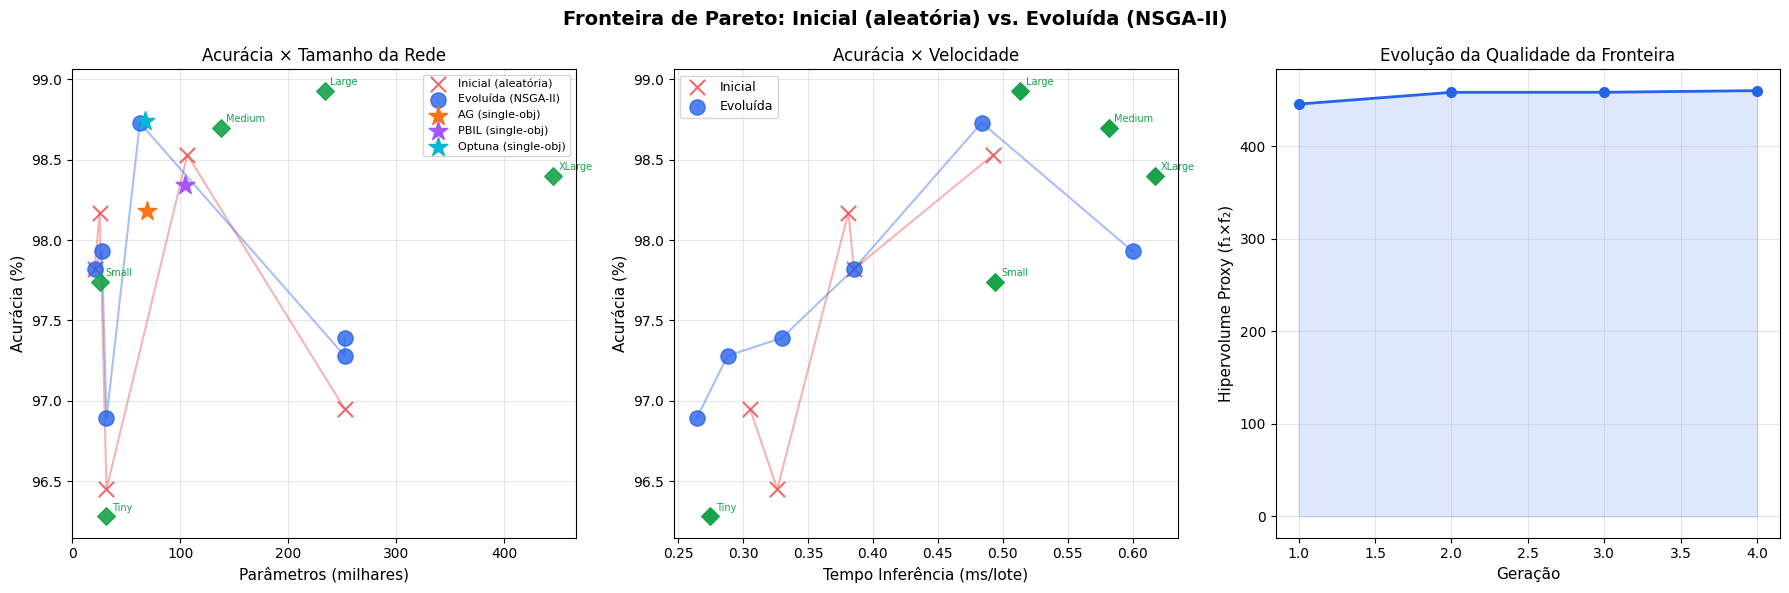

Gráfico salvo em pareto_fronts.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Fronteira de Pareto: Inicial (aleatória) vs. Evoluída (NSGA-II)', fontsize=14, fontweight='bold')

# ── Plot 1: Acurácia × Parâmetros ────────────────────────────────────────────
ax = axes[0]
def plot_pareto_set(ax, objs, cfgs, color, label, marker, zorder=2, alpha=0.8):
    xs = [obj[1] * MAX_PARAMS / 1000 for obj in objs]  # params em milhares
    ys = [100 - obj[0] for obj in objs]                # acurácia
    ax.scatter(xs, ys, c=color, marker=marker, s=120, zorder=zorder, alpha=alpha, label=label)
    # Ligar pontos da fronteira (ordenado por params)
    pts = sorted(zip(xs, ys))
    ax.plot([p[0] for p in pts], [p[1] for p in pts], c=color, alpha=0.4, linewidth=1.5)

plot_pareto_set(ax, pareto_init_objs, pareto_init_cfgs, '#ef4444', 'Inicial (aleatória)', 'x', zorder=2)
plot_pareto_set(ax, pareto_final_objs, pareto_final_cfgs, '#2563eb', 'Evoluída (NSGA-II)', 'o', zorder=3)

# Adicionar baselines como pontos de referência
for bname, bres in baseline_results.items():
    bx = bres['f2_params'] / 1000
    by = bres['f1_acc']
    ax.scatter(bx, by, c='#16a34a', marker='D', s=80, zorder=4, alpha=0.9)
    ax.annotate(bname, (bx, by), textcoords='offset points', xytext=(4, 4), fontsize=7, color='#16a34a')

ax.set_xlabel('Parâmetros (milhares)', fontsize=11)
ax.set_ylabel('Acurácia (%)', fontsize=11)
ax.set_title('Acurácia × Tamanho da Rede', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Adicionar single-obj na legenda
so_points = [('AG', obj_ag, '#f97316'), ('PBIL', obj_pbil, '#a855f7'), ('Optuna', obj_opt, '#06b6d4')]
for name, obj, c in so_points:
    ax.scatter(obj[1]/1000, obj[0], c=c, marker='*', s=200, zorder=5, label=f'{name} (single-obj)')
ax.legend(fontsize=8)

# ── Plot 2: Acurácia × Tempo de Inferência ───────────────────────────────────
ax = axes[1]
def plot_pareto_set2(ax, objs, cfgs, color, label, marker, zorder=2):
    xs = [obj[2] for obj in objs]      # inf time
    ys = [100 - obj[0] for obj in objs]
    ax.scatter(xs, ys, c=color, marker=marker, s=120, zorder=zorder, alpha=0.8, label=label)
    pts = sorted(zip(xs, ys))
    ax.plot([p[0] for p in pts], [p[1] for p in pts], c=color, alpha=0.4, linewidth=1.5)

plot_pareto_set2(ax, pareto_init_objs, pareto_init_cfgs, '#ef4444', 'Inicial', 'x', zorder=2)
plot_pareto_set2(ax, pareto_final_objs, pareto_final_cfgs, '#2563eb', 'Evoluída', 'o', zorder=3)
for bname, bres in baseline_results.items():
    ax.scatter(bres['f3_inf'], bres['f1_acc'], c='#16a34a', marker='D', s=80, zorder=4)
    ax.annotate(bname, (bres['f3_inf'], bres['f1_acc']), textcoords='offset points', xytext=(4,4), fontsize=7, color='#16a34a')
ax.set_xlabel('Tempo Inferência (ms/lote)', fontsize=11)
ax.set_ylabel('Acurácia (%)', fontsize=11)
ax.set_title('Acurácia × Velocidade', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Plot 3: Evolução do Hipervolume Proxy ────────────────────────────────────
ax = axes[2]
ax.plot(range(1, len(hist_hv)+1), hist_hv, 'o-', color='#2563eb', linewidth=2, markersize=7)
ax.fill_between(range(1, len(hist_hv)+1), hist_hv, alpha=0.15, color='#2563eb')
ax.set_xlabel('Geração', fontsize=11)
ax.set_ylabel('Hipervolume Proxy (f₁×f₂)', fontsize=11)
ax.set_title('Evolução da Qualidade da Fronteira', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pareto_fronts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em pareto_fronts.png")


## 7. 🆕 Comparação Completa

Aqui consolidamos **todos** os resultados: baseline, single-objective e multiobjetivo.


In [17]:
# ── Tabela comparativa ────────────────────────────────────────────────────────
rows = []

# Baselines
for bname, bres in baseline_results.items():
    rows.append({'Método': f'Baseline ({bname})', 'Categoria': 'Baseline',
                 'Acurácia (%)': round(bres['f1_acc'], 2),
                 'Parâmetros': bres['f2_params'],
                 'Inf Time (ms)': round(bres['f3_inf'], 2),
                 'Fitness Escalar': round(bres['fitness'], 2)})

# Single-objective
for mname, obj, cfg in [('AG', obj_ag, best_cfg_ag), ('PBIL', obj_pbil, best_cfg_pbil), ('Optuna', obj_opt, best_cfg_opt)]:
    rows.append({'Método': mname, 'Categoria': 'Single-Obj',
                 'Acurácia (%)': round(obj[0], 2),
                 'Parâmetros': int(obj[1]),
                 'Inf Time (ms)': round(obj[2], 2),
                 'Fitness Escalar': round(calculate_fitness(obj[0], obj[1]), 2)})

# NSGA-II — melhor acurácia, melhor tamanho, melhor velocidade
best_acc_nsga = max(pareto_final_objs, key=lambda o: -o[0])
best_siz_nsga = min(pareto_final_objs, key=lambda o: o[1])
best_spd_nsga = min(pareto_final_objs, key=lambda o: o[2])

for suffix, obj in [('(↑Acc)', best_acc_nsga), ('(↓Params)', best_siz_nsga), ('(↓Inf)', best_spd_nsga)]:
    rows.append({'Método': f'NSGA-II {suffix}', 'Categoria': 'Multi-Obj (Pareto)',
                 'Acurácia (%)': round(100 - obj[0], 2),
                 'Parâmetros': int(obj[1] * MAX_PARAMS),
                 'Inf Time (ms)': round(obj[2], 2),
                 'Fitness Escalar': round(calculate_fitness(100 - obj[0], obj[1] * MAX_PARAMS), 2)})

df = pd.DataFrame(rows)
df = df.sort_values(['Categoria', 'Acurácia (%)'], ascending=[True, False])
display(df.to_string(index=False))
df.to_csv('resultados_comparativos.csv', index=False)
print("\nTabela salva em resultados_comparativos.csv")


'           Método          Categoria  Acurácia (%)  Parâmetros  Inf Time (ms)  Fitness Escalar\n Baseline (Large)           Baseline         98.93      233610           0.51           100.00\nBaseline (Medium)           Baseline         98.70      137226           0.58           100.15\nBaseline (XLarge)           Baseline         98.40      445322           0.62            98.62\n Baseline (Small)           Baseline         97.74       25258           0.49            99.64\n  Baseline (Tiny)           Baseline         96.28       31530           0.27            98.15\n   NSGA-II (↑Acc) Multi-Obj (Pareto)         98.73       62442           0.48           100.48\nNSGA-II (↓Params) Multi-Obj (Pareto)         97.82       20490           0.39            99.74\n   NSGA-II (↓Inf) Multi-Obj (Pareto)         96.89       31530           0.26            98.76\n           Optuna         Single-Obj         98.74       67626           0.55           100.47\n             PBIL         Single-Obj   


Tabela salva em resultados_comparativos.csv


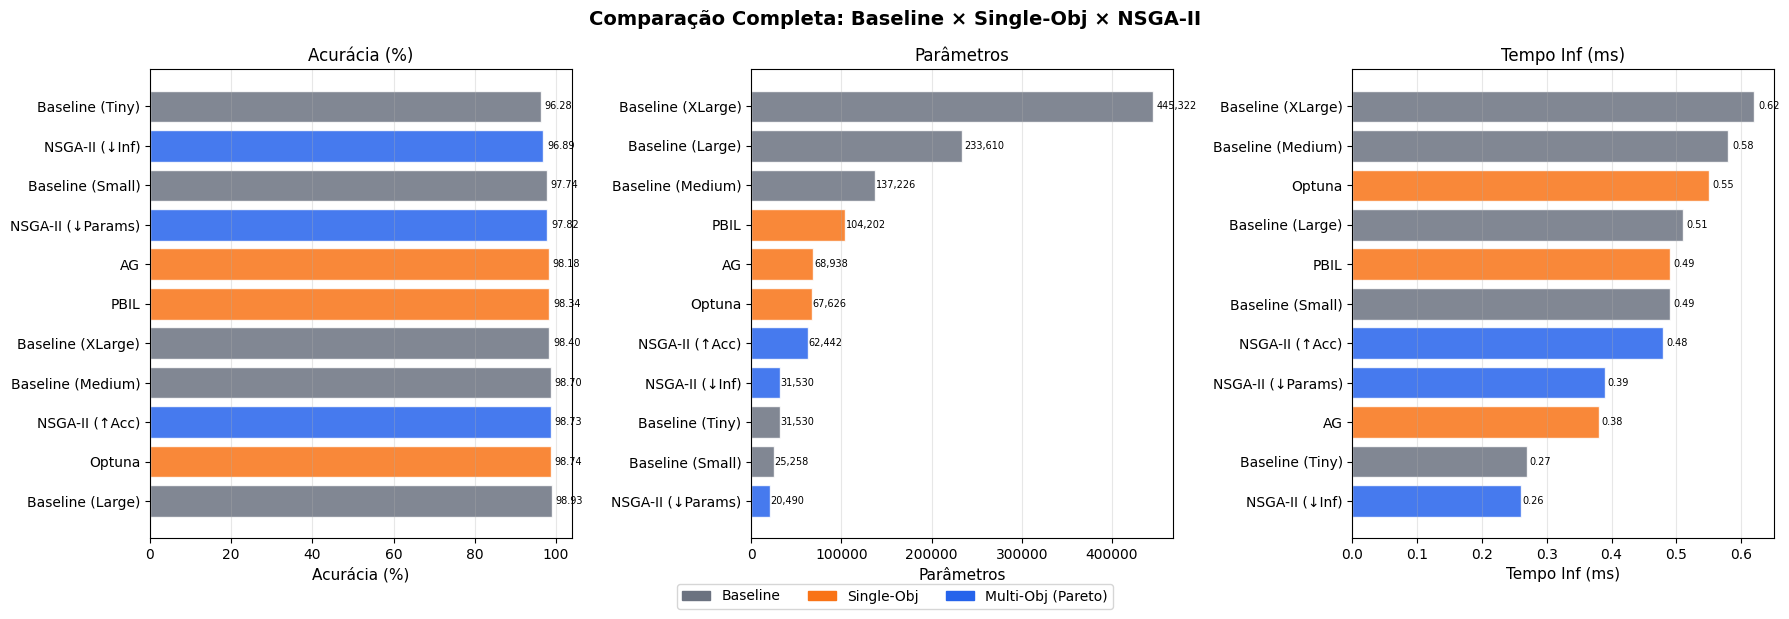

Gráfico salvo em comparacao_completa.png


In [18]:
# ── Gráfico de barras comparativo ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparação Completa: Baseline × Single-Obj × NSGA-II', fontsize=14, fontweight='bold')

cat_colors = {'Baseline': '#6b7280', 'Single-Obj': '#f97316', 'Multi-Obj (Pareto)': '#2563eb'}

for ax_i, (metric, ylabel, ascending) in enumerate([
    ('Acurácia (%)', 'Acurácia (%)', False),
    ('Parâmetros', 'Parâmetros', True),
    ('Inf Time (ms)', 'Tempo Inf (ms)', True),
]):
    ax = axes[ax_i]
    df_sorted = df.sort_values(metric, ascending=ascending)
    colors = [cat_colors[c] for c in df_sorted['Categoria']]
    bars = ax.barh(df_sorted['Método'], df_sorted[metric], color=colors, alpha=0.85, edgecolor='white')
    ax.set_xlabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, df_sorted[metric]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:,.0f}' if metric == 'Parâmetros' else f'{val:.2f}',
                va='center', fontsize=7)

# Legenda
patches = [mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.savefig('comparacao_completa.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em comparacao_completa.png")


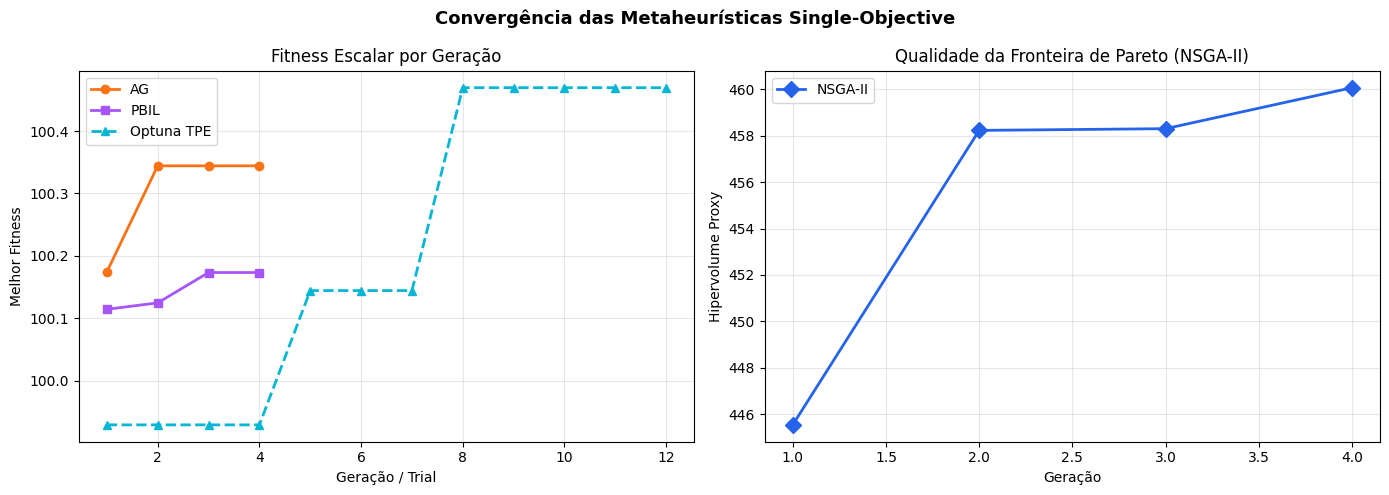

In [19]:
# ── Gráfico de convergência single-obj ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Convergência das Metaheurísticas Single-Objective', fontsize=13, fontweight='bold')

ax1.plot(range(1, len(hist_ag)+1),   hist_ag,   'o-', label='AG',         color='#f97316', linewidth=2)
ax1.plot(range(1, len(hist_pbil)+1), hist_pbil, 's-', label='PBIL',       color='#a855f7', linewidth=2)
ax1.plot(range(1, len(hist_opt)+1),  hist_opt,  '^--', label='Optuna TPE', color='#06b6d4', linewidth=2)
ax1.set_xlabel('Geração / Trial'); ax1.set_ylabel('Melhor Fitness')
ax1.set_title('Fitness Escalar por Geração'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(range(1, len(hist_hv)+1), hist_hv, 'D-', color='#2563eb', linewidth=2, markersize=8, label='NSGA-II')
ax2.set_xlabel('Geração'); ax2.set_ylabel('Hipervolume Proxy')
ax2.set_title('Qualidade da Fronteira de Pareto (NSGA-II)'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('convergencia.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Discussão de Trade-offs

##O que os resultados mostram
Nenhuma arquitetura é a melhor em tudo ao mesmo tempo. Uma rede maior acerta mais, mas é mais lenta e pesada. Uma rede pequena responde rápido e ocupa pouco espaço, mas erra mais. Esse conflito entre acurácia, tamanho e velocidade é o trade-off central do problema.
Baseline: o ponto de partida manual
As arquiteturas desenhadas à mão já funcionam bem. A Large atingiu 98,93% de acurácia, mas custa 233 mil parâmetros e 0,51ms por lote. A Tiny é a mais rápida (0,27ms) e a mais leve (31 mil parâmetros), mas só chega a 96,28%. O engenheiro consegue boas soluções, mas escolhe apenas um ponto do espaço — sem saber o que fica entre esses extremos.
##Single-objective: uma boa solução, mas só uma
AG, PBIL e Optuna encontraram arquiteturas competitivas. O Optuna teve a melhor acurácia entre os três (98,74%) com apenas 67 mil parâmetros — muito mais eficiente que o Baseline Large. O AG foi o mais rápido na inferência (0,38ms) entre os métodos automáticos. O problema é que cada um entrega apenas uma resposta, e essa resposta depende dos pesos escolhidos na função de fitness — uma decisão arbitrária feita antes de ver os dados.
NSGA-II: o mapa completo dos compromissos
##O NSGA-II não entrega uma solução apenas.
Os três pontos destacados mostram isso bem: o NSGA-II(↑Acc) chegou a 98,73% com 62 mil parâmetros, sendo mais preciso e mais leve que o Baseline Large ao mesmo tempo. O NSGA-II(↓Params) encontrou uma rede com apenas 20 mil parâmetros e 97,82% de acurácia — algo que nenhum baseline manual oferecia. O NSGA-II(↓Inf) foi o mais rápido de todos os métodos (0,26ms), rivalizando com o Baseline Tiny mas com acurácia 0,6 pontos maior.
O gráfico de hipervolume mostra que a fronteira foi melhorando a cada geração, confirmando que a evolução estava funcionando — não foi sorte da população inicial.
##Qual usar na prática?
Depende do contexto. Para um servidor sem restrição de hardware, o Baseline Large ou NSGA-II(↑Acc) são equivalentes e ambos funcionam bem. Para um dispositivo móvel ou embarcado, o NSGA-II(↓Params) entrega quase a mesma acurácia com 10× menos parâmetros que o Large. Para uma aplicação em tempo real, o NSGA-II(↓Inf) é a melhor escolha. A grande vantagem do multiobjetivo é justamente essa: você roda uma vez e escolhe depois, sem precisar reformular o problema para cada cenário.


In [21]:
# ── Resumo final numérico ────────────────────────────────────────────────────
print("="*70)
print(" RESUMO FINAL")
print("="*70)

print("\n Baseline — Melhor acurácia:")
best_bl = max(baseline_results.items(), key=lambda x: x[1]['f1_acc'])
print(f"   {best_bl[0]}: Acc={best_bl[1]['f1_acc']:.2f}%, Params={best_bl[1]['f2_params']:,}")

print("\n Single-Objective — Melhor fitness:")
so_all = [('AG', obj_ag), ('PBIL', obj_pbil), ('Optuna', obj_opt)]
best_so = max(so_all, key=lambda x: calculate_fitness(x[1][0], x[1][1]))
print(f"   {best_so[0]}: Acc={best_so[1][0]:.2f}%, Params={best_so[1][1]:,}, InfTime={best_so[1][2]:.2f}ms")

print(f"\n NSGA-II Fronteira de Pareto — {len(pareto_final_cfgs)} soluções não-dominadas:")
print(f"   Melhor acurácia: {100 - min(o[0] for o in pareto_final_objs):.2f}%")
print(f"   Menor rede:      {min(o[1]*MAX_PARAMS for o in pareto_final_objs):,.0f} params")
print(f"   Mais rápida:     {min(o[2] for o in pareto_final_objs):.2f} ms/lote")


 RESUMO FINAL

 Baseline — Melhor acurácia:
   Large: Acc=98.93%, Params=233,610

 Single-Objective — Melhor fitness:
   Optuna: Acc=98.74%, Params=67,626, InfTime=0.55ms

 NSGA-II Fronteira de Pareto — 6 soluções não-dominadas:
   Melhor acurácia: 98.73%
   Menor rede:      20,490 params
   Mais rápida:     0.26 ms/lote
